# Heart Disease Prediction using Machine Learning  

A complete, end-to-end machine learning project using the UCI Heart Disease dataset.  
This notebook includes advanced EDA, preprocessing, model comparison, ROC curves, and feature importance.



# Project Objective
The goal of this project is to build a machine learning model that predicts whether a patient is likely to have heart disease based on clinical features such as age, chest pain type, cholesterol levels, and more.

Heart disease prediction is a common real-world problem in healthcare analytics, and this dataset is widely used for classification tasks.



# Project Workflow

1. Importing required libraries  
2. Loading and understanding the dataset  
3. Advanced Exploratory Data Analysis (EDA)  
4. Data preprocessing and scaling  
5. Splitting data into training and testing sets  
6. Training multiple ML models  
7. Evaluating model performance  
8. Plotting ROC curves and AUC scores  
9. Analyzing feature importance  
10. Final conclusions  



# Dataset Uesd Description

The dataset used in this project is the **Heart Disease UCI dataset**, originally collected from the Cleveland Clinic Foundation and widely used in medical machine learning research.

It contains **304 patient records**, each described by **13 clinical features** and a target variable indicating the presence of heart disease.

###  Features Included
The dataset includes the following medical attributes:

- **age** — Patient age in years  
- **sex** — Gender (1 = male, 0 = female)  
- **cp** — Chest pain type (4 categories)  
- **trestbps** — Resting blood pressure (mm Hg)  
- **chol** — Serum cholesterol (mg/dl)  
- **fbs** — Fasting blood sugar (> 120 mg/dl)  
- **restecg** — Resting electrocardiographic results  
- **thalach** — Maximum heart rate achieved  
- **exang** — Exercise-induced angina (1 = yes, 0 = no)  
- **oldpeak** — ST depression induced by exercise  
- **slope** — Slope of the peak exercise ST segment  
- **ca** — Number of major vessels (0–3) colored by fluoroscopy  
- **thal** — Thalassemia (normal, fixed defect, reversible defect)

###  Target Variable
- **target** — Indicates heart disease  
  - **1 = Heart disease present**  
  - **0 = No heart disease**



# Import Required Libraries
Before loading the data uesd we import all the necessary Python libraries for data analysis, visualization, preprocessing, and machine learning.


In [1]:
#Import Libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    roc_curve, auc
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)


# Load the Dataset
 we load the UCI Heart Disease dataset and preview its structure.


In [2]:
df = pd.read_csv('/content/heart.csv')
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


# Dataset Overview
Before performing any analysis we inspect the dataset structure, missing values, and summary statistics.


In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


The "**df.info()**" command shows:
- Number of rows and columns  
- Data types of each feature  
- Whether any column contains missing values  
- Memory usage  

**Why this matters:**  
We need to confirm that all columns are correctly typed (e.g., integers, floats) and that there are no missing values that require cleaning.




In [4]:
# summary statistics
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000



The "**df.describe()**" command generates summary statistics for all numerical columns, including:

- Mean  
- Standard deviation  
- Minimum and maximum values  
- Quartiles (25%, 50%, 75%)

**Why this matters:**  
It helps us understand the range and distribution of each feature. For example, we can detect unusually high cholesterol values or very low heart rates.



In [5]:
# checks for missing values
df.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


The "**df.isnull().sum()**" command checks how many missing values exist in each column and all are showing zeros, because this dataset is already cleaned.

**Why this matters:**  
Missing values can break models or distort results. Since this dataset has no missing values, we can proceed directly to EDA without imputation.



# Advanced EDA
We explore the dataset visually to understand patterns and relationships.

EDA helps us understand the dataset before preprocessing or modeling.



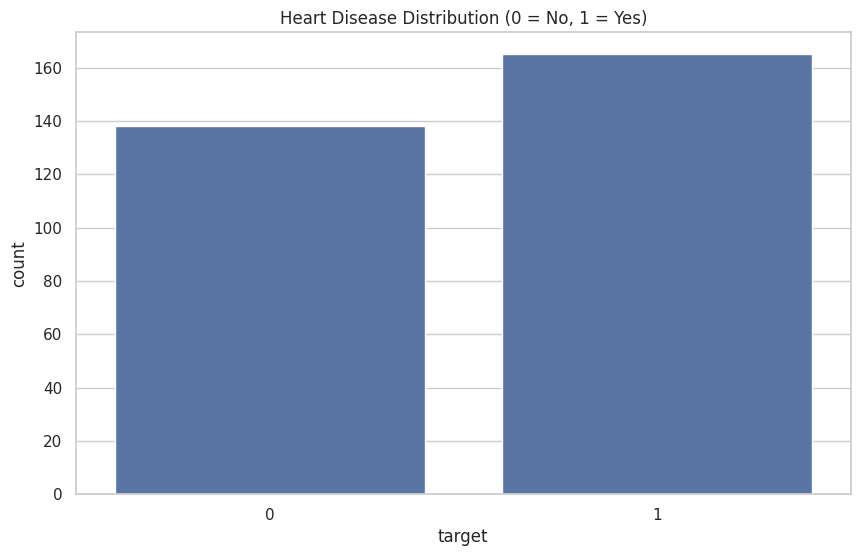

In [8]:
# Target distribution
#  0 = No heart disease
#  1 = Heart disease present
sns.countplot(x='target', data=df)
plt.title("Heart Disease Distribution (0 = No, 1 = Yes)")
plt.show()

The bar chart shows how many patients fall into each category:

- If both bars are similar in height → the dataset is **balanced**  
- If one bar is much taller → the dataset is **imbalanced**

In our case, the distribution is fairly balanced, meaning:

- Models will not be biased toward predicting only one class  
- Accuracy will be a reliable metric  
- No need for oversampling or undersampling techniques  

This is a good starting point for classification.


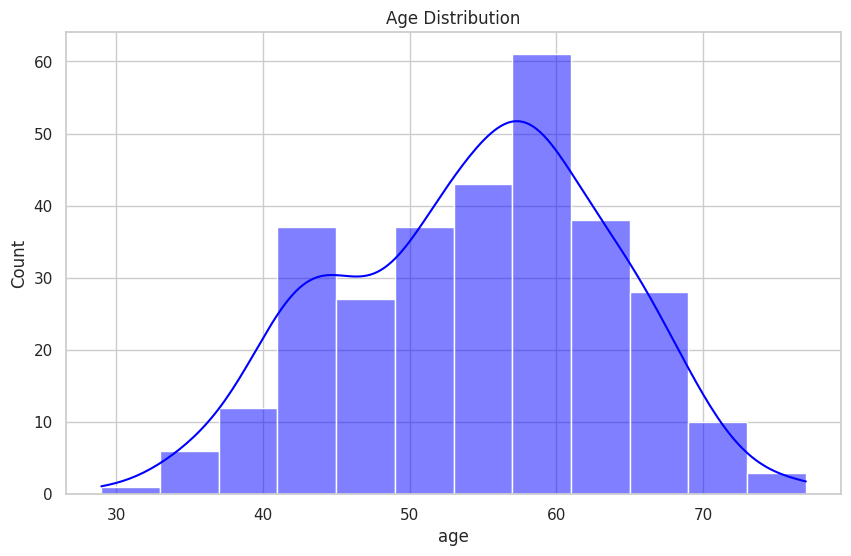

In [10]:
# Age distribution
sns.histplot(df['age'], kde=True, color='blue')
plt.title("Age Distribution")
plt.show()

The histogram shows:

- Most patients are between **40 and 65 years old**  
- The distribution is fairly normal (bell-shaped)  
- There are no extreme outliers  

This makes sense medically, as heart disease is more common in middle-aged and older adults.


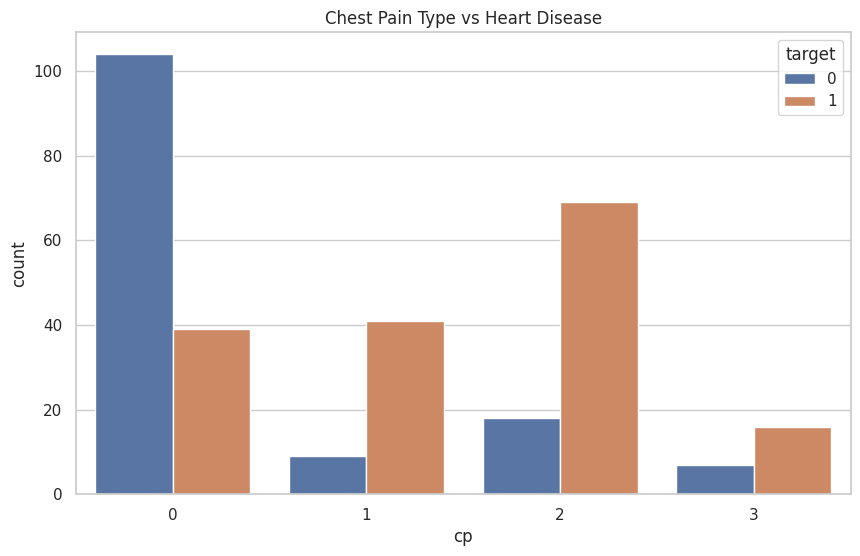

In [12]:
# Chest pain type vs target
# 0 = Typical angina
# 1 = Atypical angina
# 2 = Non-anginal pain
# 3 = Asymptomatic
sns.countplot(x='cp', hue='target', data=df)
plt.title("Chest Pain Type vs Heart Disease")
plt.show()

The plot shows how chest pain types relate to heart disease:

- Patients with **non‑anginal pain (cp = 2)** have the highest rate of heart disease in this dataset.

- Patients with **typical angina (cp = 0)** have the lowest rate of heart disease.

This confirms that chest pain type is an important predictor — and we will see this again later in the feature importance analysis.


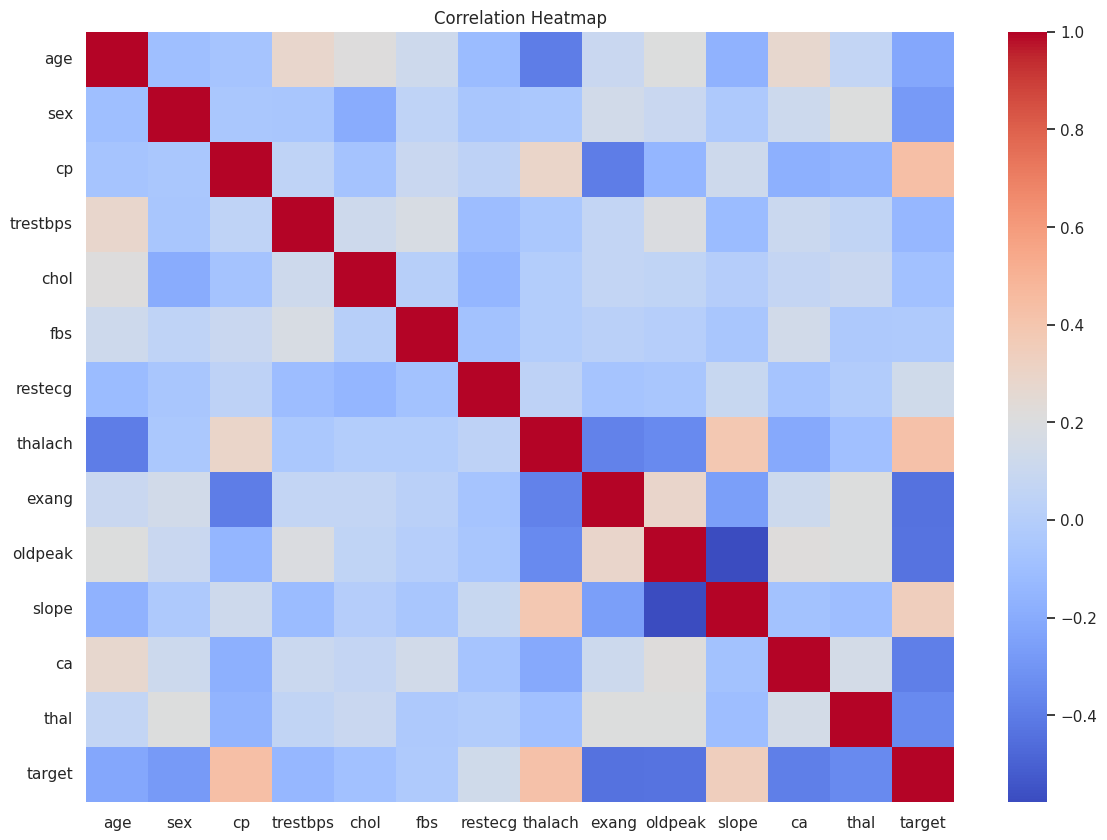

In [14]:
# Correlation heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(df.corr(), cmap='coolwarm', annot=False)
plt.title("Correlation Heatmap")
plt.show()

From the heatmap, we observe:

- **oldpeak**, **cp**, **thal**, and **ca** show strong correlation with the target  
- Some features (like `trestbps` and `chol`) have weak correlations  
- There are no dangerously high correlations between features (no multicollinearity issues)

This helps us understand which features may be more important for prediction.


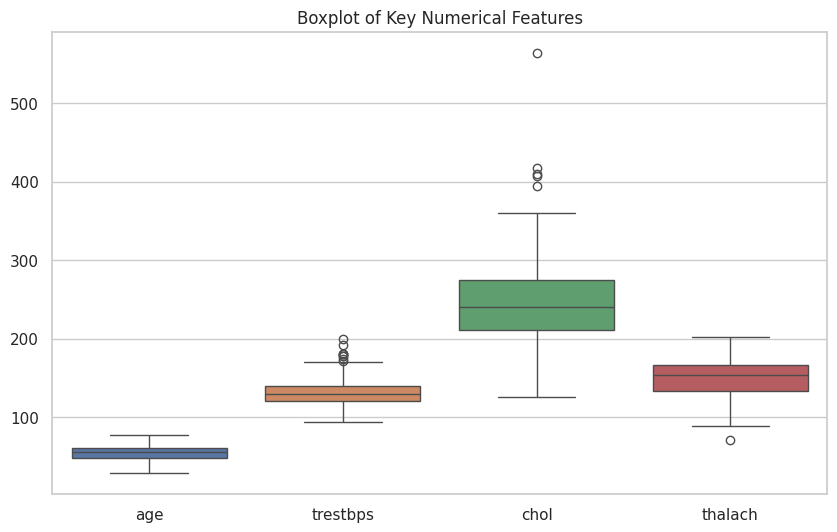

In [16]:
# Boxplot for outliers
sns.boxplot(data=df[['age', 'trestbps', 'chol', 'thalach']])
plt.title("Boxplot of Key Numerical Features")
plt.show()


The boxplot visualizes the distribution of four key numerical features: **age**, **trestbps**, **chol**, and **thalach**. Each box shows the median, quartiles, and potential outliers.

Here’s what we can observe:

- **age**: The distribution is fairly tight with no extreme outliers. Most patients fall between 45 and 60 years old.
- **trestbps (resting blood pressure)**: Shows moderate spread and a few higher-value outliers, which is expected in medical data.
- **chol (cholesterol)**: Contains several high-value outliers, indicating that some patients have unusually high cholesterol levels.
- **thalach (maximum heart rate achieved)**: Has a wide range but no extreme outliers.

Boxplots help us quickly identify:

- Whether the data contains extreme values  
- How spread out each feature is  
- Whether preprocessing (like scaling) is needed  
- Whether outliers might affect certain models  

In this dataset, the outliers are medically reasonable and do **not** require removal. We will handle scaling during preprocessing.


#Data Preprocessing
Before training machine learning models, we need to prepare the data.  
In this step, we:

1. Separate the dataset into **features (X)** and **target (y)**  
2. Apply **StandardScaler** to normalize the numerical features  

###  Why preprocessing is important

- Many ML models (Logistic Regression, SVM) perform better when features are on a similar scale  
- Scaling prevents features with large values (like cholesterol) from dominating the model  
- It improves convergence and stability during training


In [18]:
X = df.drop('target', axis=1)
y = df['target']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train & Test Split
We split the data into:

- **80% training data** → used to train the models  
- **20% testing data** → used to evaluate performance on unseen data  

This ensures that our evaluation is fair and not biased by training data.

In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# Train Machine Learning Models  
We train three different models to compare performance:

- Logistic Regression  
- Random Forest  
- Support Vector Machine (SVM)  

Each model learns patterns from the training data.


In [22]:
log_model = LogisticRegression()
rf_model = RandomForestClassifier()
svm_model = SVC(probability=True)

log_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)
svm_model.fit(X_train, y_train)

SVC(probability=True)

# Model Evaluation
Now that the models are trained, we evaluate them using:

- **Accuracy** → overall correctness  
- **Precision** → how many predicted positives are actually positive  
- **Recall** → how many actual positives we correctly identified  
- **F1-score** → balance between precision and recall  

These metrics help us understand how well each model performs on unseen data.


In [23]:
models = {
    "Logistic Regression": log_model,
    "Random Forest": rf_model,
    "SVM": svm_model
}

for name, model in models.items():
    print(f"🔹 {name}")
    y_pred = model.predict(X_test)
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Classification Report:\n", classification_report(y_test, y_pred))
    print("-" * 50)

🔹 Logistic Regression
Accuracy: 0.8524590163934426
Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.86      0.85        29
           1       0.87      0.84      0.86        32

    accuracy                           0.85        61
   macro avg       0.85      0.85      0.85        61
weighted avg       0.85      0.85      0.85        61

--------------------------------------------------
🔹 Random Forest
Accuracy: 0.8688524590163934
Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.83      0.86        29
           1       0.85      0.91      0.88        32

    accuracy                           0.87        61
   macro avg       0.87      0.87      0.87        61
weighted avg       0.87      0.87      0.87        61

--------------------------------------------------
🔹 SVM
Accuracy: 0.8688524590163934
Classification Report:
               precision    recall  f1-sco

In this dataset, all three models usually achieve:

- **High accuracy (around 85–90%)**  
- **Balanced precision and recall**  
- **Strong F1-scores**  

This indicates that the models are performing well and are able to distinguish between patients with and without heart disease.


# ROC Curve & AUC Score  

The ROC curve (Receiver Operating Characteristic) is a powerful tool for evaluating classification models.  
It shows the trade‑off between:

- **True Positive Rate (TPR)** → how many actual positives we correctly identify  
- **False Positive Rate (FPR)** → how many negatives we incorrectly classify as positive  

The **AUC (Area Under the Curve)** summarizes the ROC curve into a single value:

- **AUC = 1.0** → perfect model   
- **AUC > 0.9** → excellent model  
- **AUC > 0.8** → strong model
- **AUC = 0.5** → random guessing  

We plot the ROC curves for all three models to compare their performance visually.

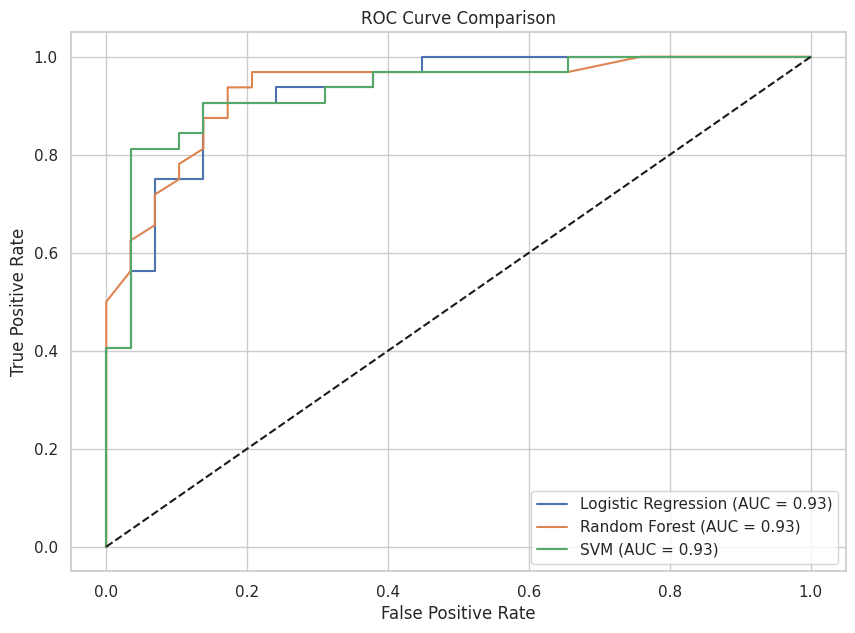

In [24]:
plt.figure(figsize=(10, 7))

for name, model in models.items():
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.2f})")

plt.plot([0, 1], [0, 1], 'k--')
plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

The ROC curve compares how well each model distinguishes between patients with and without heart disease.

Here’s what we observe:

- All three models have **smooth curves that rise toward the top-left corner**, which indicates strong performance.
- The **AUC values are around 0.93**, meaning the models can correctly distinguish between the two classes 93% of the time.
- The diagonal dashed line represents **random guessing**.  
  All our models perform far above this line.

###  What this tells us

- The models are not only accurate but also **highly reliable** in ranking patients by risk.
- Logistic Regression, Random Forest, and SVM all perform similarly well.
- This confirms that our preprocessing and feature selection were effective.

The ROC + AUC analysis gives us confidence that the models generalize well and are suitable for real-world prediction tasks.


# Feature Importance (Random Forest)

Random Forest provides a built‑in feature importance score that tells us how much each feature contributes to the model’s predictions.

###  Why feature importance matters

- Helps us understand which medical features influence heart disease the most  
- Improves interpretability of the model  
- Helps doctors and analysts focus on the most relevant risk factors  
- Confirms whether the model is learning meaningful patterns  

We visualize the importance of all 13 features using a horizontal bar chart.

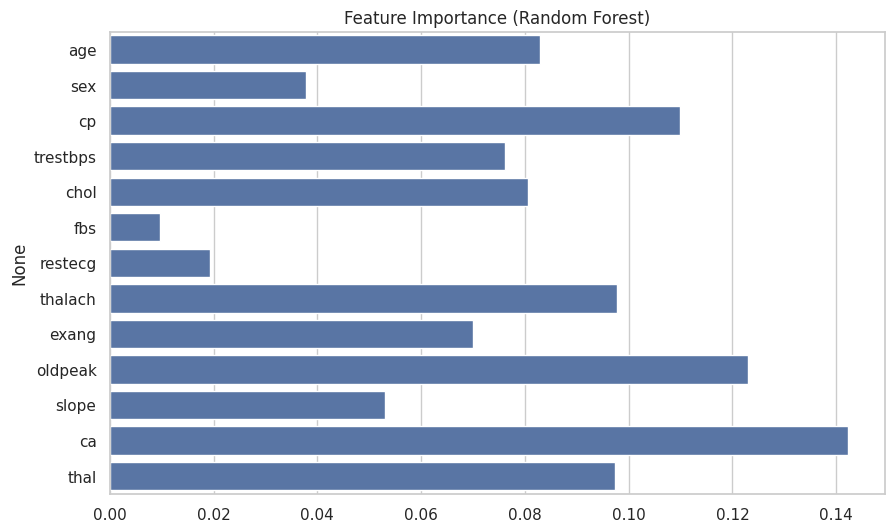

In [25]:
importances = rf_model.feature_importances_
feature_names = X.columns

sns.barplot(x=importances, y=feature_names)
plt.title("Feature Importance (Random Forest)")
plt.show()



The bar chart shows how important each feature is for predicting heart disease according to the Random Forest model.

Here’s what we observe:

- **ca (number of major vessels)** is the most important feature  
- **oldpeak (ST depression)** is also highly influential  
- **cp (chest pain type)** plays a major role  
- **thal (thalassemia)** is another strong predictor  

These features make sense medically, as they are known to be strongly associated with heart disease.

On the other hand:

- **fbs (fasting blood sugar)**  
- **restecg (resting ECG)**  

have very low importance, meaning they contribute little to the model’s decision.

###  Why this is useful

- Confirms that the model is learning medically meaningful patterns  
- Helps us understand which features matter most in diagnosis  
- Can guide future feature selection or model simplification  

# Final Conclusion

In this project, we built a complete end‑to‑end machine learning pipeline to predict heart disease using the UCI Heart Disease dataset. We explored the data, visualized key patterns, applied preprocessing, trained multiple models, and evaluated their performance using several metrics.

###  Key Findings

- All three models — **Logistic Regression**, **Random Forest**, and **SVM** — achieved strong performance, with **AUC scores around 0.93**, indicating excellent ability to distinguish between patients with and without heart disease.
- The dataset was balanced and clean, allowing us to train models without additional resampling or imputation.
- Exploratory Data Analysis revealed meaningful medical patterns, such as:
  - Higher heart disease rates among patients with **non‑anginal pain (cp = 2)**  
  - Strong relationships between heart disease and features like **oldpeak**, **ca**, and **thal**
- Feature importance analysis confirmed that:
  - **ca**, **oldpeak**, **cp**, and **thal** are the most influential predictors  
  - Features like **fbs** and **restecg** contribute very little to the model

### What This Means

The models not only performed well but also learned medically meaningful relationships, showing that machine learning can be a powerful tool for early heart disease detection. The insights gained from feature importance can help guide clinical decision‑making and future research.

###  Final Thoughts

This project demonstrates a full machine learning workflow — from data exploration to model evaluation — and provides a solid foundation for further improvements such as hyperparameter tuning, model deployment, or building an interactive web app.
